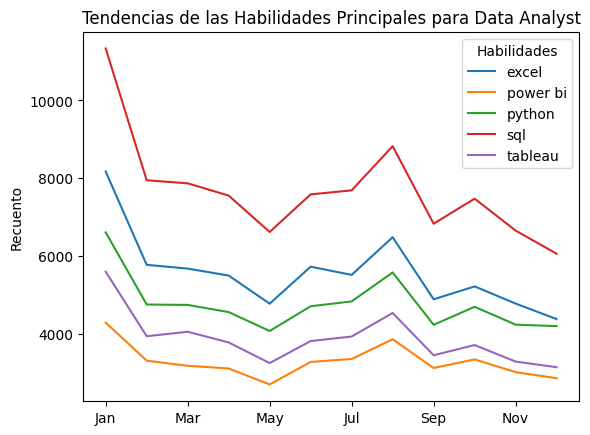

In [11]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import calendar


dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)



df = df[df["job_title_short"] == "Data Analyst"]
df_exploded = df.explode("job_skills")
df_exploded["job_posted_month"] = df_exploded["job_posted_date"].dt.month
top_5_skills= df_exploded["job_skills"].value_counts().head(5).index.tolist()
tabla = df_exploded.groupby("job_posted_month")["job_skills"].value_counts()
skill_count = tabla.reset_index(name="skill_count")
skill_count= skill_count[skill_count["job_skills"].isin(top_5_skills)]
pivot = skill_count.pivot_table(index= "job_posted_month", columns="job_skills", values="skill_count")
pivot.index = [calendar.month_abbr[i] for i in pivot.index]

pivot.plot(kind="line")
plt.title("Tendencias de las Habilidades Principales para Data Analyst")
plt.ylabel('Recuento')
plt.xlabel('')
plt.legend(title='Habilidades')
plt.show()

